# Conteo y caracterización de múltiples objetos
Bounding box recto, bounding box rotado, círculo mínimo, convex hull y dirección (eje mayor).

In [1]:
ruta_img = "hojas.png"

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from numpy import intp
from scipy import ndimage

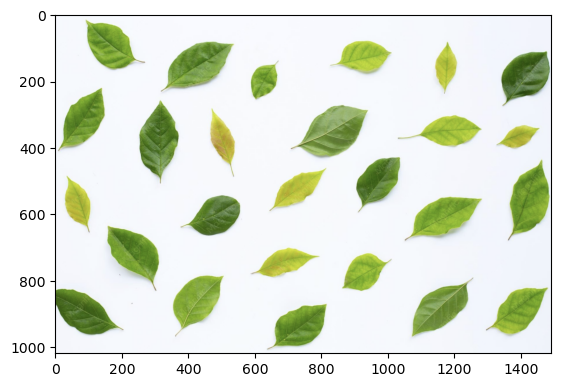

In [3]:
imagen = cv2.imread(ruta_img)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

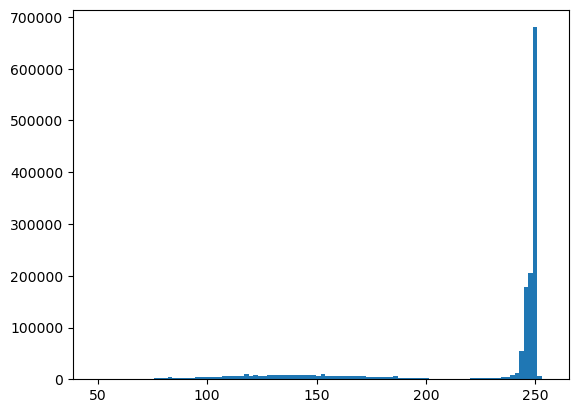

In [4]:
I = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
vector = I.flatten()
plt.hist(vector, bins=100);

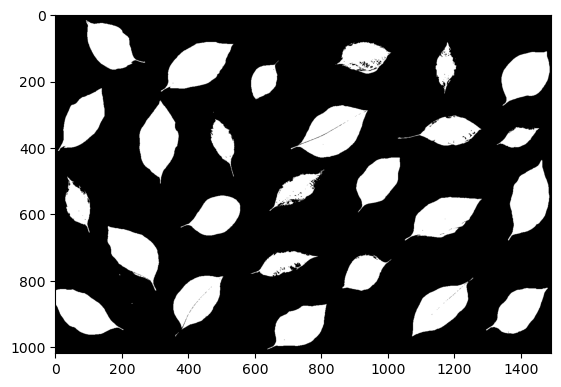

In [5]:
umbral, _ = cv2.threshold(I, 0, 255, cv2.THRESH_OTSU)
# Si los objetos son OSCUROS sobre fondo CLARO -> (I < umbral)
# Si los objetos son CLAROS sobre fondo OSCURO -> (I > umbral)
binaria = np.uint8((I < umbral) * 255)
plt.imshow(binaria, cmap='gray')

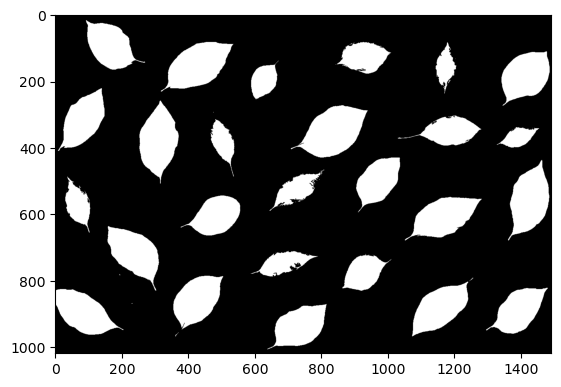

In [6]:
binaria = ndimage.binary_fill_holes(binaria).astype(np.uint8) * 255
plt.imshow(binaria, cmap='gray')

In [7]:
salida = cv2.connectedComponentsWithStats(binaria, 2, cv2.CV_32S)
cantidadDeObjetos = salida[0]
etiquetas = salida[1]
estadisticas = salida[2]

# Filtro por área mínima para descartar ruido (ajusta según imagen)
area_min = 200
indices_validos = [i for i in range(1, cantidadDeObjetos) if estadisticas[i, 4] >= area_min]
print(f"Objetos detectados (sin ruido): {len(indices_validos)}")

Objetos detectados (sin ruido): 26


In [8]:
contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Filtramos contornos pequeños igual que con stats
contornos = [c for c in contornos if cv2.contourArea(c) >= area_min]
print(f"Contornos válidos: {len(contornos)}")

Contornos válidos: 26


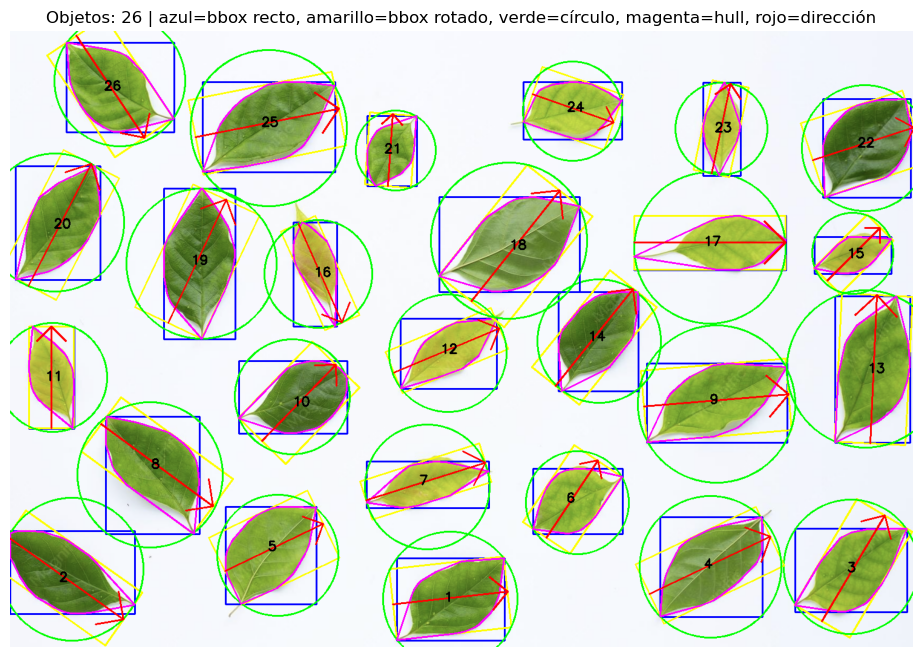

In [9]:
# Dibujamos todo sobre una copia
salida_img = imagen.copy()
m, n = binaria.shape

for idx, cnt in enumerate(contornos, start=1):
    # --- Bounding box recto ---
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(salida_img, (x, y), (x + w, y + h), (255, 0, 0), 2)  # azul

    # --- Bounding box rotado (mínimo) ---
    rectangulo = cv2.minAreaRect(cnt)
    caja = cv2.boxPoints(rectangulo)
    caja = np.intp(caja)
    cv2.drawContours(salida_img, [caja], 0, (0, 255, 255), 2)  # amarillo

    # --- Círculo mínimo envolvente ---
    (cx, cy), radio = cv2.minEnclosingCircle(cnt)
    cv2.circle(salida_img, (int(cx), int(cy)), int(radio), (0, 255, 0), 2)  # verde

    # --- Convex hull ---
    hull = cv2.convexHull(cnt)
    cv2.drawContours(salida_img, [hull], 0, (255, 0, 255), 2)  # magenta

    # --- Dirección (eje mayor del minAreaRect) ---
    (centro_x, centro_y), (ancho, alto), angulo = rectangulo
    # El lado mayor define la orientación principal
    if ancho < alto:
        angulo = angulo + 90
    largo = max(ancho, alto) / 2
    rad = np.deg2rad(angulo)
    p1 = (int(centro_x - largo * np.cos(rad)), int(centro_y - largo * np.sin(rad)))
    p2 = (int(centro_x + largo * np.cos(rad)), int(centro_y + largo * np.sin(rad)))
    cv2.arrowedLine(salida_img, p1, p2, (0, 0, 255), 2, tipLength=0.2)  # rojo

    # --- Etiqueta numérica ---
    cv2.putText(salida_img, str(idx), (int(centro_x) - 10, int(centro_y) + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(salida_img, cv2.COLOR_BGR2RGB))
plt.title(f"Objetos: {len(contornos)} | azul=bbox recto, amarillo=bbox rotado, verde=círculo, magenta=hull, rojo=dirección")
plt.axis('off');

In [10]:
# Tabla resumen por objeto
for idx, cnt in enumerate(contornos, start=1):
    area = cv2.contourArea(cnt)
    perimetro = cv2.arcLength(cnt, True)
    (_, _), (a, b), ang = cv2.minAreaRect(cnt)
    if a < b:
        ang = ang + 90
    print(f"Obj {idx}: área={area:.0f}, perímetro={perimetro:.1f}, ángulo={ang:.1f}°")

Obj 1: área=14338, perímetro=554.7, ángulo=-6.3°
Obj 2: área=15814, perímetro=576.4, ángulo=35.2°
Obj 3: área=13706, perímetro=553.4, ángulo=-59.4°
Obj 4: área=15832, perímetro=564.5, ángulo=-25.6°
Obj 5: área=15220, perímetro=557.4, ángulo=-25.6°
Obj 6: área=9137, perímetro=455.4, ángulo=-56.3°
Obj 7: área=6884, perímetro=669.1, ángulo=-17.5°
Obj 8: área=16050, perímetro=609.3, ángulo=36.2°
Obj 9: área=16426, perímetro=670.3, ángulo=-4.8°
Obj 10: área=12533, perímetro=502.7, ángulo=-45.8°
Obj 11: área=6418, perímetro=571.3, ángulo=-90.0°
Obj 12: área=6972, perímetro=746.0, ángulo=-22.8°
Obj 13: área=17450, perímetro=637.4, ángulo=-87.3°
Obj 14: área=12764, perímetro=520.8, ángulo=-51.3°
Obj 15: área=4002, perímetro=351.7, ángulo=-45.0°
Obj 16: área=5630, perímetro=486.8, ángulo=66.0°
Obj 17: área=10486, perímetro=707.2, ángulo=0.0°
Obj 18: área=20504, perímetro=689.8, ángulo=-51.5°
Obj 19: área=17334, perímetro=609.0, ángulo=-64.8°
Obj 20: área=14323, perímetro=569.5, ángulo=-62.8°
Ob